Saving data_01.csv to data_01.csv


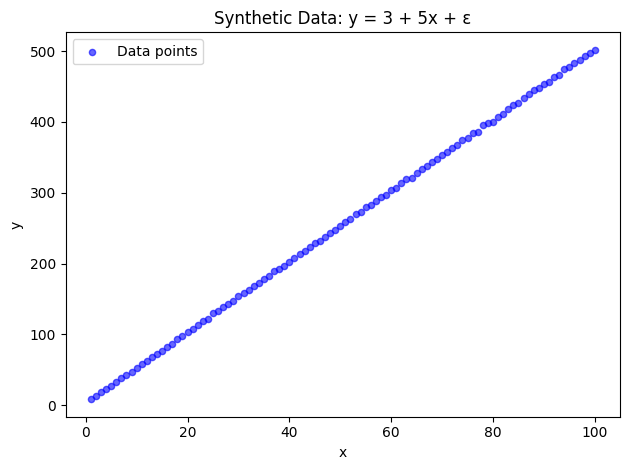

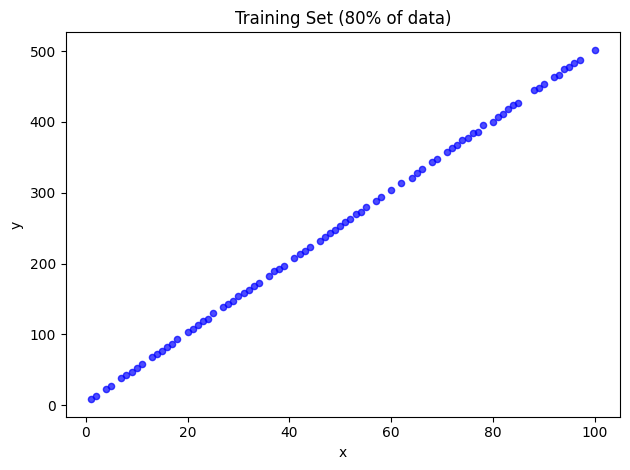

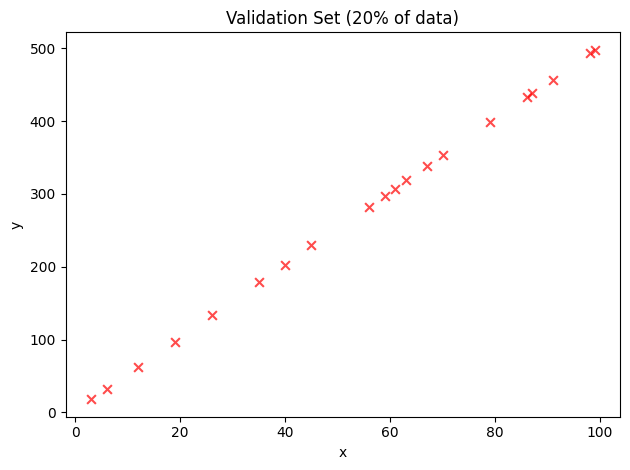


Trying Gradient Descent without scaling:
 alpha=0.0001, final validation error=1.1518581289270071
 alpha=0.0005, final validation error=1.0704357485277896
 alpha=0.001, final validation error=inf


/tmp/ipython-input-8207547.py:42: RuntimeWarning: overflow encountered in matmul
  return (err @ err) / (2.0 * m)


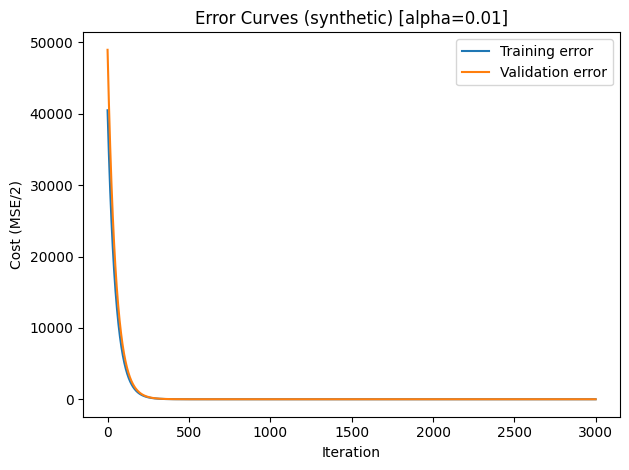

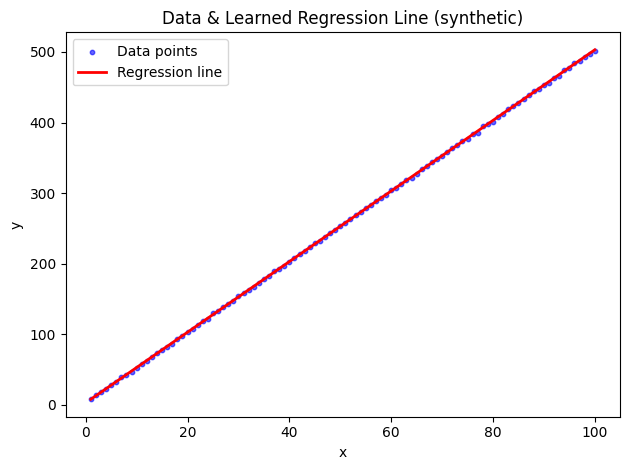


Synthetic run (with scaling):
 alpha: 0.01
 final training error: 0.4391140355006481
 final validation error: 0.2859122540895895
 best validation error: 0.27853124902622656
 training error at best val error: 0.44527413403049076
 θ0 (intercept): 249.69412871982274
 θ1 (slope): 142.4415894043233

Real dataset not found. Skipping real run.


In [1]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_data(df: pd.DataFrame):
    X = df["x"].values.astype(float).reshape(-1, 1)
    y = df["y"].values.astype(float)
    return X, y

def add_dummy_feature(X):
    # dummy x0 with all 1s
    X = np.asarray(X).reshape(-1, 1) if X.ndim == 1 else np.asarray(X)
    return np.hstack([np.ones((X.shape[0], 1)), X])

def feature_scale(Xb):
    X0 = Xb[:, [0]]
    Xn = Xb[:, 1:]
    mu = Xn.mean(axis=0)
    sigma = Xn.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1.0
    Xn_scaled = (Xn - mu) / sigma
    return np.hstack([X0, Xn_scaled]), mu, sigma

def process_data(X, y, test_size=0.2, seed=519, scale=True):
    # Split 80%-20% for training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=seed)
    Xb_train = add_dummy_feature(X_train)
    Xb_val   = add_dummy_feature(X_val)
    mu = sigma = None
    if scale: # feature scale if requested
        Xb_train, mu, sigma = feature_scale(Xb_train)
        Xb_val = np.hstack([np.ones((Xb_val.shape[0], 1)), (Xb_val[:, 1:] - mu) / sigma])
    return (X_train, y_train, X_val, y_val, Xb_train, y_train, Xb_val, y_val), (mu, sigma)

def compute_cost(X, y, theta):
    m = y.shape[0]
    err = X @ theta - y  # vectorized dot product
    return (err @ err) / (2.0 * m)

def gradient_descent(X_train, y_train, X_val, y_val, alpha=0.01, num_iters=2000, theta0=None):
    # Implement linear regression with gradient descent
    m, n = X_train.shape
    theta = np.zeros(n) if theta0 is None else theta0.astype(float).copy()
    train_cost, val_cost = [], []
    best = {"theta": theta.copy(), "train_cost": None, "val_cost": np.inf, "iter": 0}

    for it in range(1, num_iters + 1):
        preds = X_train @ theta       # hypothesis hθ(x) = Xθ, vectorized dot product
        grad = (X_train.T @ (preds - y_train)) / m    # ∇J(θ)
        theta -= alpha * grad

        jt = compute_cost(X_train, y_train, theta)
        jv = compute_cost(X_val, y_val, theta)
        train_cost.append(jt)
        val_cost.append(jv)

        if jv < best["val_cost"]:
            best = {"theta": theta.copy(), "train_cost": jt, "val_cost": jv, "iter": it}

    hist = {"train_cost": np.array(train_cost), "val_cost": np.array(val_cost), "best": best}
    return theta, hist

def evaluate(X, y, theta):
    preds = X @ theta   # vectorized dot product
    mse = ((preds - y) ** 2).mean()
    return mse, preds

def plot_error_curves(hist, title, out_path):
    plt.figure()
    plt.plot(hist["train_cost"], label="Training error")
    plt.plot(hist["val_cost"], label="Validation error")
    plt.xlabel("Iteration")
    plt.ylabel("Cost (MSE/2)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()

def plot_fit(X, y, theta, mu, sigma, title, out_path):
    Xb_full = add_dummy_feature(X)
    if mu is not None and sigma is not None:
        Xb_full = np.hstack([np.ones((Xb_full.shape[0], 1)), (Xb_full[:, 1:] - mu) / sigma])
    _, preds = evaluate(Xb_full, y, theta)  # vectorized dot product
    order = np.argsort(X.ravel())
    plt.figure()
    plt.scatter(X, y, s=10, color="blue", alpha=0.6, label="Data points")
    plt.plot(X[order], preds[order], linewidth=2, color="red", label="Regression line")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()

if __name__ == "__main__":
    # 100 data for y = 3 + 5x + noise
    rng = np.random.default_rng(519)
    x = np.arange(1, 101, dtype=float) # x from 0 to 100
    y = 3.0 + 5.0 * x + rng.normal(0.0, 1.0, size=x.shape[0])
    syn_df = pd.DataFrame({"x": x, "y": y})
    syn_df.to_csv("lab01_data.csv", index=False)

    # Data plot
    plt.figure()
    plt.scatter(x, y, s=20, color="blue", alpha=0.6, label="Data points")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title("Synthetic Data: y = 3 + 5x + ε")
    plt.legend()
    plt.tight_layout()
    plt.savefig("1.synthetic_data_points.png")
    plt.show()
    plt.close()

    # Split 80%-20% for training and validation sets
    X, y = load_data(syn_df)
    (Xtr_raw, ytr, Xva_raw, yva, Xtr, ytr, Xva, yva), (mu, sigma) = process_data(X, y, scale=False)

    # Separate plots training set and validation set
    plt.figure()
    plt.scatter(Xtr_raw, ytr, s=20, color="blue", alpha=0.7)
    plt.title("Training Set (80% of data)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()
    plt.savefig("2.synthetic_training_set.png")
    plt.show()
    plt.close()

    plt.figure()
    plt.scatter(Xva_raw, yva, s=40, color="red", alpha=0.7, marker="x")
    plt.title("Validation Set (20% of data)")
    plt.xlabel("x"); plt.ylabel("y")
    plt.tight_layout()
    plt.savefig("3.synthetic_validation_set.png")
    plt.show()
    plt.close()

    # Gradient Descent — try without scaling first
    print("\nTrying Gradient Descent without scaling:")
    for a in (0.0001, 0.0005, 0.001):
        _, hist_tmp = gradient_descent(Xtr, ytr, Xva, yva, alpha=a, num_iters=500)
        print(f" alpha={a}, final validation error={hist_tmp['val_cost'][-1]}")

    # Gradient Descent — try with scaling
    (Xtr_raw, ytr, Xva_raw, yva, Xtr, ytr, Xva, yva), (mu, sigma) = process_data(X, y, scale=True)
    best = None

    # Implement linear regression with gradient descent
    for a in (0.01, 0.05, 0.1):
        th, hist = gradient_descent(Xtr, ytr, Xva, yva, alpha=a, num_iters=3000)
        score = hist["best"]["val_cost"]
        if best is None or score < best[0]:
            best = (score, a, th, hist)
    _, alpha, theta, hist = best

    # Plot training and validation error curve same plot
    plot_error_curves(hist, f"Error Curves (synthetic) [alpha={alpha}]", "4.synthetic_error_curves.png")
    plot_fit(X, y, theta, mu, sigma, "Data & Learned Regression Line (synthetic)", "5.synthetic_fit.png")

    # Print final training, validation, best validation, corresponding training error for synthetic data
    print("\nSynthetic run (with scaling):")
    print(" alpha:", alpha)
    print(" final training error:", hist["train_cost"][-1])
    print(" final validation error:", hist["val_cost"][-1])
    print(" best validation error:", hist["best"]["val_cost"])
    print(" training error at best val error:", hist["best"]["train_cost"])
    print(" θ0 (intercept):", theta[0])
    print(" θ1 (slope):", theta[1]) # print values of the parameters of the learnt model

    # Real dataset (if available)
    try:
        real_df = pd.read_csv("data_01_extracted.csv")  # must contain ['x','y']
        Xr, yr = load_data(real_df)
        (Xtr_raw, ytr, Xva_raw, yva, Xtr, ytr, Xva, yva), (mu, sigma) = process_data(Xr, yr, scale=True)

        best = None
        for a in (0.001, 0.005, 0.01):
            th, hist_r = gradient_descent(Xtr, ytr, Xva, yva, alpha=a, num_iters=5000)
            score = hist_r["best"]["val_cost"]
            if best is None or score < best[0]:
                best = (score, a, th, hist_r)
        _, alpha_r, theta_r, hist_r = best

        # Plot training and validation error curve same plot
        plot_error_curves(hist_r, f"Error Curves (real data) [alpha={alpha_r}]", "6.real_data_error_curves.png")
        plot_fit(Xr, yr, theta_r, mu, sigma, "Data & Learned Regression Line (real data)", "7.real_data_fit.png")

        # Print final training, validation, best validation, corresponding training error for real data
        print("\nReal run (with scaling):")
        print(" alpha:", alpha_r)
        print(" final training error:", hist_r["train_cost"][-1])
        print(" final validation error:", hist_r["val_cost"][-1])
        print(" best validation error:", hist_r["best"]["val_cost"])
        print(" training error at best val error:", hist_r["best"]["train_cost"])
        print(" θ0 (intercept):", theta_r[0])
        print(" θ1 (slope):", theta_r[1])
    except FileNotFoundError:
        print("\nReal dataset not found. Skipping real run.")
